<center> <img src = https://raw.githubusercontent.com/AndreyRysistov/DatasetsForPandas/main/hh%20label.jpg alt="drawing" style="width:400px;">

# <center> Проект: Анализ резюме из HeadHunter
   

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Изучение данных

In [2]:
hh_data = pd.read_csv('data/dst-3.0_16_1_hh_database.csv', sep=';')

hh_data.shape

(44744, 12)

In [3]:
display(hh_data.head())

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
0,"Мужчина , 39 лет , родился 27 ноября 1979",29000 руб.,Системный администратор,"Советск (Калининградская область) , не готов к...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...",Опыт работы 16 лет 10 месяцев Август 2010 — п...,"МАОУ ""СОШ № 1 г.Немана""",Системный администратор,Неоконченное высшее образование 2000 Балтийск...,16.04.2019 15:59,Имеется собственный автомобиль
1,"Мужчина , 60 лет , родился 20 марта 1959",40000 руб.,Технический писатель,"Королев , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Опыт работы 19 лет 5 месяцев Январь 2000 — по...,Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",Высшее образование 1981 Военно-космическая ак...,12.04.2019 08:42,Не указано
2,"Женщина , 36 лет , родилась 12 августа 1982",20000 руб.,Оператор,"Тверь , не готова к переезду , не готова к ком...",полная занятость,полный день,Опыт работы 10 лет 3 месяца Октябрь 2004 — Де...,ПАО Сбербанк,Кассир-операционист,Среднее специальное образование 2002 Профессио...,16.04.2019 08:35,Не указано
3,"Мужчина , 38 лет , родился 25 июня 1980",100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"Саратов , не готов к переезду , готов к редким...","частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",Опыт работы 18 лет 9 месяцев Август 2017 — Ап...,OpenSoft,Инженер-программист,Высшее образование 2002 Саратовский государст...,08.04.2019 14:23,Не указано
4,"Женщина , 26 лет , родилась 3 марта 1993",140000 руб.,Региональный менеджер по продажам,"Москва , не готова к переезду , готова к коман...",полная занятость,полный день,Опыт работы 5 лет 7 месяцев Региональный мене...,Мармелад,Менеджер по продажам,Высшее образование 2015 Кгу Психологии и педаг...,22.04.2019 10:32,Не указано


In [4]:
hh_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

In [5]:
hh_data.describe()

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
count,44744,44744,44744,44744,44744,44744,44576,44743,44742,44744,44744,44744
unique,16003,690,14929,10063,38,47,44413,30214,16927,40148,18838,2
top,"Мужчина , 32 года , родился 17 сентября 1986",50000 руб.,Системный администратор,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,Индивидуальное предпринимательство / частная п...,Системный администратор,Высшее образование 2014 Тюменский Государствен...,07.05.2019 09:50,Не указано
freq,18,4064,3099,1261,30026,22727,3,935,2062,4,25,32268


В целом вид данных понятен, видны пропуски и неверные типы данных.

## Предобработка данных 

### 1. Преобразование признака "Образование и ВУЗ"

У нас есть столбец "Образование и ВУЗ", в котором указаны уровень образования, год выпуска и ВУЗ. Нас интересует только уровень образования.  
- Отредактируем данные и создадим новый столбец "Образование" с четырьмя категориями: высшее, неоконченное высшее, среднее специальное, среднее.  
- После этого удалим исходный столбец "Образование и ВУЗ".  


In [6]:
hh_data['Образование'] = hh_data['Образование и ВУЗ'].apply(lambda x: ' '.join(str(x).split()[:2]).lower())

education_categories = ['высшее', 'неоконченное высшее', 'среднее специальное', 'среднее']

replace_dict = {
    'высшее образование': 'высшее',
    'среднее образование': 'среднее'
}

hh_data['Образование'] = hh_data['Образование'].replace(replace_dict)

hh_data = hh_data.drop(columns=['Образование и ВУЗ'])

hh_data['Образование'].value_counts()



Образование
высшее                 33863
среднее специальное     5765
неоконченное высшее     4557
среднее                  559
Name: count, dtype: int64

### 2. Преобразование признака "Пол, возраст"

Берём столбец "Пол, возраст", в котором указаны пол, возраст и дата рождения.
Выделим из него два отдельных столбца: "Пол" и "Возраст".

- Пол преобразуем в два значения: 'М' для мужчин и 'Ж' для женщин.
- Возраст приведём к целым числам.
- После этого удалим исходный столбец "Пол, возраст".


In [7]:
sex = {
    'мужчина': 'M',
    'женщина': 'Ж'
}

hh_data['Пол'] = hh_data['Пол, возраст'].str.split(',').str[0].str.strip().str.lower()
hh_data['Пол'] = hh_data['Пол'].replace(sex)


hh_data['Возраст'] = hh_data['Пол, возраст'].str.split(',').str[1].str.strip().str.split(' ').str[0].astype(int)

hh_data.drop(columns=['Пол, возраст'], inplace=True)


После обработки посмотрим на процент женщин среди всех соискателей и рассчитаем средний возраст соискателей

In [8]:
percent_sex_w = round(hh_data['Пол'].value_counts(normalize=True)['Ж'] * 100, 2)
print("Процент женских резюме: ", percent_sex_w)

average_age = round(hh_data['Возраст'].mean(), 1)
print("\nСредний возраст соискателей:", average_age)

Процент женских резюме:  19.07

Средний возраст соискателей: 32.2


### 3. Преобразование признака "Опыт работы"

Берём столбец "Опыт работы" и выделяем из него общий стаж соискателя в месяцах. Новый столбец назовём "Опыт работы (месяц)".

Особенности, которые учитываем при преобразовании:

- Пропуски оставляем как есть (NaN).

- Скрытые пропуски вроде "Не указано" тоже преобразуем в NaN.
- Нам нужна только информация об общем опыте, периоды работы в разных компаниях игнорируем.
- Опыт работы может быть указан только в годах, только в месяцах или сразу в годах и месяцах.

После преобразования удаляем исходный столбец "Опыт работы".


In [9]:
months_types = ['месяца', 'месяцев', 'месяц']
years_types = ['год', 'года', 'лет']

number_words = {
    'ноль':0, 'один':1, 'два':2, 'три':3, 'четыре':4, 'пять':5,
    'шесть':6, 'семь':7, 'восемь':8, 'девять':9, 'десять':10,
    'одиннадцать':11, 'двенадцать':12
}

def experience_in_months(text):
    if pd.isna(text) or text == 'Не указано':
        return np.nan

    years = 0
    months = 0
    
    parts = text.split(' ')[:6]

    # ищем "год" и "лет"
    for i, word in enumerate(parts):
        if word in months_types:
            prev = parts[i-1].lower()
            if prev in number_words:
                months = number_words[prev]
            else:
                try:
                    months = int(prev)
                except ValueError:
                    months = 0
        if word in years_types:
            prev = parts[i-1].lower()
            if prev in number_words:
                years = number_words[prev]
            else:
                try:
                    years = int(prev)
                except ValueError:
                    years = 0
            
    return years * 12 + months
    


hh_data['Опыт работы (месяц)'] = hh_data['Опыт работы'].apply(experience_in_months)

hh_data.drop(columns=['Опыт работы'], inplace=True)

display(hh_data['Опыт работы (месяц)'].median())


np.float64(100.0)

Опыт работы успешно приведён к числовому виду.
Медианный стаж соискателей составляет 100 месяцев (~8 лет).

### 4. Преобразование признака "Город, переезд, командировки"

Рассматриваем столбец "Город, переезд, командировки", который содержит информацию о городе проживания, готовности к переезду и командировкам.  

Выделим из него три отдельных признака: "Город", "Готовность к переезду", "Готовность к командировкам".  

Что делаем:  
- Извлекаем город и приводим его к категориям: Москва, Санкт-Петербург, город-миллионник, другие. Список городов-миллионников задан отдельно в коде.
- Информацию о метро игнорируем.
- Готовность к переезду приводим к булевому значению (True / False), учитывая разные формулировки.
- Готовность к командировкам также приводим к True / False. Если информация отсутствует, считаем, что кандидат не готов к командировкам.

После преобразований удаляем исходный столбец "Город, переезд, командировки".


In [10]:
million_cities = ['Новосибирск', 'Екатеринбург', 'Нижний Новгород', 'Казань', 'Челябинск', 'Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж', 'Волгоград' ]


def parse_city(text: str) -> str:
    if not isinstance(text, str) or text.strip() == "":
        return np.nan
    
    parts = [p.strip() for p in text.split(',')]
    city = parts[0]

    if city == 'Москва':
        return 'Москва'
    elif city == 'Санкт-Петербург':
        return 'Санкт-Петербург'
    elif city in million_cities:
        return 'город-миллионник'
    else:
        return 'другие'

def parse_relocate(text: str) -> bool:
    if not isinstance(text, str):
        return False
    
    text_lower = text.lower()
    if 'не готов' in text_lower and 'переезд' in text_lower:
        return False
    if 'готов' in text_lower and 'переезд' in text_lower:
        return True
    if 'хочу переехать' in text_lower:
        return True
    return False


def parse_travel(text: str) -> bool:
    if not isinstance(text, str):
        return False
    
    text_lower = text.lower()
    if 'не готов к командировкам' in text_lower or 'не готова к командировкам' in text_lower:
        return False
    if 'готов к командировкам' in text_lower or 'готова к командировкам' in text_lower:
        return True
    if 'редким командировкам' in text_lower:
        return True
    return False

hh_data['Город'] = hh_data['Город, переезд, командировки'].apply(parse_city)
hh_data['Готовность к переезду'] = hh_data['Город, переезд, командировки'].apply(parse_relocate)
hh_data['Готовность к командировкам'] = hh_data['Город, переезд, командировки'].apply(parse_travel)

hh_data.drop(columns=['Город, переезд, командировки'], inplace=True)

display(hh_data.head())

# Задание 3.4
percent_spb = round(hh_data['Город'].value_counts(normalize=True)['Санкт-Петербург']* 100, 0)
print(f"Процент людей из Санкт-Петербурга: {percent_spb}%")

percent_ready_move = hh_data['Готовность к переезду'].mean()
percent_ready_travel = hh_data['Готовность к командировкам'].mean()
percent_both = ((hh_data['Готовность к переезду']) & (hh_data['Готовность к командировкам'])).mean() * 100
print('Процент людей готовых к перезду и к командировкам',round(percent_both, 0))


,ЗП,Ищет работу на должность:,Занятость,График,Последнее/нынешнее место работы,Последняя/нынешняя должность,Обновление резюме,Авто,Образование,Пол,Возраст,Опыт работы (месяц),Город,Готовность к переезду,Готовность к командировкам
0,29000 руб.,Системный администратор,"частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, ва...","МАОУ ""СОШ № 1 г.Немана""",Системный администратор,16.04.2019 15:59,Имеется собственный автомобиль,неоконченное высшее,M,39,202.0,другие,False,False
1,40000 руб.,Технический писатель,"частичная занятость, проектная работа, полная ...","гибкий график, полный день, сменный график, уд...",Временный трудовой коллектив,"Менеджер проекта, Аналитик, Технический писатель",12.04.2019 08:42,Не указано,высшее,M,60,233.0,другие,False,True
2,20000 руб.,Оператор,полная занятость,полный день,ПАО Сбербанк,Кассир-операционист,16.04.2019 08:35,Не указано,среднее специальное,Ж,36,123.0,другие,False,False
3,100000 руб.,Веб-разработчик (HTML / CSS / JS / PHP / базы ...,"частичная занятость, проектная работа, полная ...","гибкий график, удаленная работа",OpenSoft,Инженер-программист,08.04.2019 14:23,Не указано,высшее,M,38,225.0,другие,False,True
4,140000 руб.,Региональный менеджер по продажам,полная занятость,полный день,Мармелад,Менеджер по продажам,22.04.2019 10:32,Не указано,высшее,Ж,26,67.0,Москва,False,True


Процент людей из Санкт-Петербурга: 11.0%
Процент людей готовых к перезду и к командировкам 32.0


Проведён анализ распределения кандидатов по географии и мобильности. 

Рассчитаем доли соискателей из Санкт-Петербурга, а также показатели готовности к переезду и командировкам, включая их пересечение:

In [11]:
percent_spb = round(hh_data['Город'].value_counts(normalize=True)['Санкт-Петербург']* 100, 0)
print(f"Процент людей из Санкт-Петербурга: {percent_spb}%")

percent_ready_move = round(hh_data['Готовность к переезду'].mean() * 100, 0)
print(f"Процент людей, готовых к переезду: {percent_ready_move}%")

percent_ready_travel = round(hh_data['Готовность к командировкам'].mean() * 100, 0)
print(f"Процент людей, готовых к командировкам: {percent_ready_travel}%")

percent_both = round(((hh_data['Готовность к переезду']) & (hh_data['Готовность к командировкам'])).mean() * 100, 0)
print(f"Процент людей, готовых и к переезду, и к командировкам: {percent_both}%")

Процент людей из Санкт-Петербурга: 11.0%
Процент людей, готовых к переезду: 32.0%
Процент людей, готовых к командировкам: 71.0%
Процент людей, готовых и к переезду, и к командировкам: 32.0%


Из полученных результатов можно сделать вывод что **все, кто готов к переезду → уже готовы к командировкам**

### 5. Преобразование признаков "Занятость" и "График"

Признаки "Занятость" и "График" содержат несколько категорий в одной строке, например:  
- полная занятость, проектная работа
- вахтовый метод, гибкий график, удаленная работа

Для анализа удобнее создать отдельный бинарный столбец для каждой категории: если категория указана соискателем — True, иначе — False.  
При помощи метода ```One Hot Encoding```.

После преобразования удалим исходные столбцы "Занятость" и "График".  

In [12]:
# --- Найдем все возможные варианты занятости и графиков ---

all_employment = hh_data['Занятость'].dropna().str.split(', ')
employment_categories = list({x for sublist in all_employment for x in sublist})

all_schedule = hh_data['График'].dropna().str.split(', ')
schedule_categories = list({x for sublist in all_schedule for x in sublist})


# --- Создадим признаки мигалки ---

for cat in employment_categories:
    hh_data[cat] = hh_data['Занятость'].fillna('').apply(lambda x: cat in x)

for cat in schedule_categories:
    hh_data[cat] = hh_data['График'].fillna('').apply(lambda x: cat in x)
    
    
# --- Удалим столбцы график и занятость ---

hh_data.drop(columns=['Занятость'], inplace=True)
hh_data.drop(columns=['График'], inplace=True)



Посмотрим какое количество соискателей ищущих проектную работу и волонтерство, а также количество людей заинтересованных в работе вахтовым методом с гибким графиком

In [13]:
count_project_volunteer = ((hh_data['проектная работа']) & (hh_data['волонтерство'])).sum()
print(f"Количество людей, ищущих проектную работу и волонтерство: {count_project_volunteer}")

count_shift_flexible = ((hh_data['вахтовый метод']) & (hh_data['гибкий график'])).sum()
print(f"Количество людей, желающих работать вахтовым методом и с гибким графиком: {count_shift_flexible}")

Количество людей, ищущих проектную работу и волонтерство: 436
Количество людей, желающих работать вахтовым методом и с гибким графиком: 2311


### 6. Преобразование признака "ЗП"

Признак "ЗП" содержит сумму и валюту (например, 30000 руб., 550 USD). Нам нужно перевести всё в рубли.

Шаги:
- Преобразуем "Обновление резюме" и столбец с датой курса валют в формат datetime.
- Выделим из "ЗП" число и валюту, приведём валюту к ISO коду.
- Загрузим таблицу с курсами валют (```ExchangeRates = pd.read_csv('data/ExchangeRates.csv'```).   
- Присоединим таблицу с курсами к данным резюме по дате и валюте. Для рублей курс = 1.  
- Рассчитаем зарплату в рублях: сумма * курс / пропорция и запишем в новый столбец "ЗП (руб)".  


Таблича ExchangeRates содержит следующие столбцы:  
**"currency"** – код валюты (ISO),  
**"date"** – дата курса,  
**"proportion"** – сколько единиц валюты учитывается в курсе,  
**"close"** – курс на эту дату. 

После преобразования удаляем исходный столбец "ЗП" и все промежуточные.

In [14]:
currency_map = {
    'грн.': 'UAH',
    'USD': 'USD',
    'EUR': 'EUR',
    'бел.руб.': 'BYN',
    'KGS': 'KGS',
    'сум': 'UZS',
    'AZN': 'AZN',
    'KZT': 'KZT',
    'руб.': 'RUB'
}


# --- Приведем значения в признаках "Обновление резюме" и "date" к datetime ---
ExchangeRates = pd.read_csv('data/ExchangeRates.csv')
ExchangeRates['date'] = pd.to_datetime(ExchangeRates['date'], format='%d/%m/%y').dt.date
hh_data['Обновление резюме'] = pd.to_datetime(hh_data['Обновление резюме'], dayfirst=True).dt.date


# --- Приводим ЗП к формату ISO ---
hh_data['salary_currency'] = hh_data['ЗП'].apply(lambda x: x.split()[-1])
hh_data['salary_amount'] = hh_data['ЗП'].apply(lambda x: ''.join(x.split()[:-1]))
hh_data['salary_amount'] = hh_data['salary_amount'].str.replace(' ', '').astype(float)
hh_data['salary_currency'] = hh_data['salary_currency'].str.strip().map(currency_map)


# --- Добавляем курс Рубля на все уникальные даты ---
ExchangeRates = ExchangeRates[['currency', 'date', 'close', 'proportion']]
rub_dates = pd.DataFrame({
    'currency': ['RUB'] * ExchangeRates['date'].nunique(),
    'date': ExchangeRates['date'].unique(),
    'close': 1,
    'proportion': 1
})
ExchangeRates = pd.concat([ExchangeRates, rub_dates], ignore_index=True)


# --- Обединяем таблицы и считаем ЗП в рублях ---
merged_data = hh_data.merge(
    ExchangeRates,
    left_on=['salary_currency', 'Обновление резюме'],
    right_on=['currency', 'date'],
    how='left'  # left join, чтобы все резюме остались
)
merged_data['ЗП (руб)'] = (merged_data['salary_amount'] * merged_data['close'] / merged_data['proportion']).round(2)


# --- Удаляем все не нужное ---
merged_data.drop(columns=['salary_currency'], inplace=True)
merged_data.drop(columns=['salary_amount'], inplace=True)
merged_data.drop(columns=['currency'], inplace=True)
merged_data.drop(columns=['date'], inplace=True)
merged_data.drop(columns=['close'], inplace=True)
merged_data.drop(columns=['proportion'], inplace=True)
merged_data.drop(columns=['ЗП'], inplace=True)

display(round(merged_data['ЗП (руб)'].median() / 1000,))
merged_data.info()

59

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Ищет работу на должность:        44744 non-null  object 
 1   Последнее/нынешнее место работы  44743 non-null  object 
 2   Последняя/нынешняя должность     44742 non-null  object 
 3   Обновление резюме                44744 non-null  object 
 4   Авто                             44744 non-null  object 
 5   Образование                      44744 non-null  object 
 6   Пол                              44744 non-null  object 
 7   Возраст                          44744 non-null  int64  
 8   Опыт работы (месяц)              44574 non-null  float64
 9   Город                            44744 non-null  object 
 10  Готовность к переезду            44744 non-null  bool   
 11  Готовность к командировкам       44744 non-null  bool   
 12  стажировка        

## Исследование зависимостей в данных

1. Построим распределение признака **"Возраст"** и изучим его основные характеристики:  
- мода распределения  
- минимальное и максимальное значение  
- диапазон возраста большинства соискателей  
- наличие аномальных значений

In [15]:
import plotly
import plotly.express as px

In [16]:
# --- Гистограмма ---
fig_hist = px.histogram(
    merged_data,
    x="Возраст",
    nbins=100,
    height=400,
    width=700,
    title="Распределение возраста соискателей - Histogram",
    color_discrete_sequence=["red"]
)
fig_hist.show()

fig_hist.write_html("plotly_graphics/Распределение возраста соискателей - Histogram.html")

# --- Boxplot ---
fig_box = px.box(
    merged_data,
    x="Возраст",
    height=400,
    width=700,
    title="Распределение возраста соискателей - Boxplot",
    color_discrete_sequence=["green"]
)
fig_box.show()
fig_box.write_html("plotly_graphics/Распределение возраста соискателей - Boxplot.html")


**Выводы:**  
- Мода возраста: 30 лет.  
- Диапазон: 1–49 лет, большинство соискателей в возрасте 27–36 лет (межквартильный размах).  
- Аномалии: редкие выбросы, например возраст около 100 лет.



2. Посмотрим на распределение признака **"Опыт работы (месяц)"**: 
- определим моду
- минимальные и максимальные значения
- типичный интервал для большинства соискателей
- проверим на наличие аномалий

In [17]:
# --- Гистограмма ---
fig_hist = px.histogram(
    merged_data,
    x="Опыт работы (месяц)",
    nbins=1500,
    height=400,
    width=1000,
    title="Распределение опыта работы соискателей - Histogram",
    color_discrete_sequence=["red"]
)
fig_hist.show()
fig_hist.write_html("plotly_graphics/Распределение опыта работы соискателей - Histogram.html")

# --- Boxplot ---
fig_box = px.box(
    merged_data,
    x="Опыт работы (месяц)",
    height=400,
    width=1000,
    title="Распределение опыта работы соискателей - Boxplot",
    color_discrete_sequence=["green"]
)
fig_box.show()
fig_box.write_html("plotly_graphics/Распределение опыта работы соискателей - Boxplot.html")

Выводы:
- Мода распределения: 81 месяц

- Предельные значения и основной интервал: опыт работы варьируется от 1 до 299 месяцев, при этом 50% соискателей находятся в диапазоне от 57 до 154 месяцев (межквартильный размах), что отражает типичный опыт работы большинства кандидатов.

- Аномалии: значение 1188 месяцев явно отличается от остальных данных и считается выбросом, так как оно значительно превышает верхнюю границу типичного диапазона.

3. Анализируем распределение признака **"ЗП (руб)"**:  
- Найдем предельные значения заработной платы  
- Примерный интервал для большинства соискателей  
- Выявим аномалии  

In [18]:
# --- Гистограмма ---
fig_hist = px.histogram(
    merged_data,
    x="ЗП (руб)",
    nbins=1000,
    height=400,
    width=1000,
    title="Распределение ожидаемой заработной платы соискателей - Histogram",
    color_discrete_sequence=["red"]
)
fig_hist.show()
fig_hist.write_html("plotly_graphics/Распределение ожидаемой заработной платы соискателей - Histogram.html")

# --- Boxplot ---
fig_box = px.box(
    merged_data,
    x="ЗП (руб)",
    height=400,
    width=1000,
    title="Распределение ожидаемой заработной платы соискателей - Boxplot",
    color_discrete_sequence=["green"]
)
fig_box.show()

fig_box.write_html("plotly_graphics/Распределение ожидаемой заработной платы соискателей - Boxplot.html")

Выводы:
- Мода распределения: примерно от 25 000 до 75 000 руб. — это наиболее часто встречающийся уровень зарплаты среди кандидатов.

- Предельные значения и основной интервал: заработная плата варьируется от 1 рубля до 180 900,5 руб., при этом 50% соискателей находятся в диапазоне от 37 054,8 до 95 000 руб.

- Аномалии: значение 24 304 880 руб. явно выбивается за пределы типичного диапазона и считается аномальным, так как значительно превышает зарплату большинства соискателей. Из-за этого аномального значения графики становятся плохо читаемыми, и основная масса данных на них выглядит сжатой внизу.

4. Анализируем зависимость медианной зарплаты (**"ЗП (руб)"**) от уровня образования (**"Образование"**) (берём резюме с ЗП < 1 млн руб):  

- Определим уровни образования с наибольшей медианной зарплатой  
- Определим уровни образования с наименьшей медианной зарплатой  

In [19]:
filtered_data = merged_data[merged_data["ЗП (руб)"] < 1_000_000]

# Группируем по уровню образования и рассчитываем медианную зарплату
median_salary = filtered_data.groupby("Образование")["ЗП (руб)"].median().reset_index()

# Строим столбчатую диаграмму
fig = px.bar(
    median_salary,
    x="Образование",
    y="ЗП (руб)",
    height=400,
    width=1000,
    title="Распределение медианной желаемой заработной платы по уровню образования",
    text="ЗП (руб)",
    color="ЗП (руб)",
    color_continuous_scale="Blues"
)
fig.show()

fig.write_html("plotly_graphics/Распределение медианной желаемой заработной платы по уровню образования - Bar plot.html")

Выводы: 
- Наибольшие медианные зарплаты наблюдаются у соискателей с высшим образованием или неоконченным высшим образованием.

- Наименьшие медианные зарплаты — у соискателей со средним и средним специальным образованием.

- Итог: уровень образования оказывает заметное влияние на желаемую заработную плату и может быть важным признаком при прогнозировании.


5. Проанализируем распределение зарплаты (**"ЗП (руб)"**) по городам (резюме с ЗП < 1 млн руб):  

- Сравниваем медианные значения ЗП в разных городах  
- Оцениваем размах ЗП в каждом городе  
- Оценим значимость признака города для прогнозирования ЗП

In [20]:
filtered_data = merged_data[merged_data["ЗП (руб)"] < 1_000_000]

# Группируем по уровню образования и рассчитываем медианную зарплату
median_salary = filtered_data.groupby("Город")["ЗП (руб)"].median().reset_index()
# Строим столбчатую диаграмму
fig_bar = px.bar(
    median_salary,
    x="Город",
    y="ЗП (руб)",
    height=400,
    width=1000,
    title="Распределение медианной желаемой заработной платы по городам",
    text="ЗП (руб)",
    color="ЗП (руб)",
    color_continuous_scale="Blues"
)
fig_bar.show()

fig_bar.write_html("plotly_graphics/Распределение медианной желаемой заработной платы по городам - Bar plot.html")

fig_box = px.box(
    filtered_data,
    x="ЗП (руб)",
    y="Город",
    points="all",  # показывает все отдельные точки
    color="Город",
    title="Распределение медианной желаемой заработной платы по городам"
)
fig_box.show()

fig_box.write_html("plotly_graphics/Распределение медианной желаемой заработной платы по городам - Boxplot.html")

Выводы: 
- Чем крупнее город, тем выше медианная зарплата. Крупные города (Москва и Санкт-Петербург) показывают больший разброс.

- Город является важным фактором: видно, что медианы и распределения по городам различаются. Даже при одинаковом опыте работы или уровне образования, кандидаты из Москвы в среднем ожидают более высокую зарплату, чем из других городов.


6. Посмотроим многоуровневую столбчатую диаграмму медианной ЗП (**"ЗП (руб)"**) в зависимости от **"Готовность к переезду"** и **"Готовность к командировкам"** и:  

- Сравним медианную зарплату между соискателями, готовыми и неготовыми к переезду  
- Сравним медианную зарплату между соискателями, готовыми и неготовыми к командировкам  
- Оценим сочетание двух признаков и влияние мобильности на ожидаемую зарплату

In [21]:
median_salary = merged_data.groupby(['Готовность к переезду', 'Готовность к командировкам'])['ЗП (руб)'].median().reset_index()

fig = px.bar(
    median_salary,
    x='Готовность к переезду',
    y='ЗП (руб)',
    color='Готовность к командировкам',
    barmode='group',  # 'group' – для многоуровневой диаграммы
    title='Распределение медианной желаемой заработной платы по готовности к переезду и командировкам',
    text='ЗП (руб)'
)

fig.show()

fig.write_html("plotly_graphics/Распределение медианной желаемой заработной платы по готовности к переезду и командировкам - Bar plot.html")

Вывод:  
- Из графика отчетливо видно, что соискатели, готовые к переезду, получают более высокую зарплату по сравнению с теми, кто не готов. То же касается и соискателей, готовых к командировкам: их заработная плата выше, чем у кандидатов, которые не готовы.

7. Построим сводную таблицу, иллюстрирующую зависимость **медианной** желаемой заработной платы от возраста (**"Возраст"**) и образования (**"Образование"**). На основании этой таблицы построим **тепловую карту** и сравним показатели внутри групп.

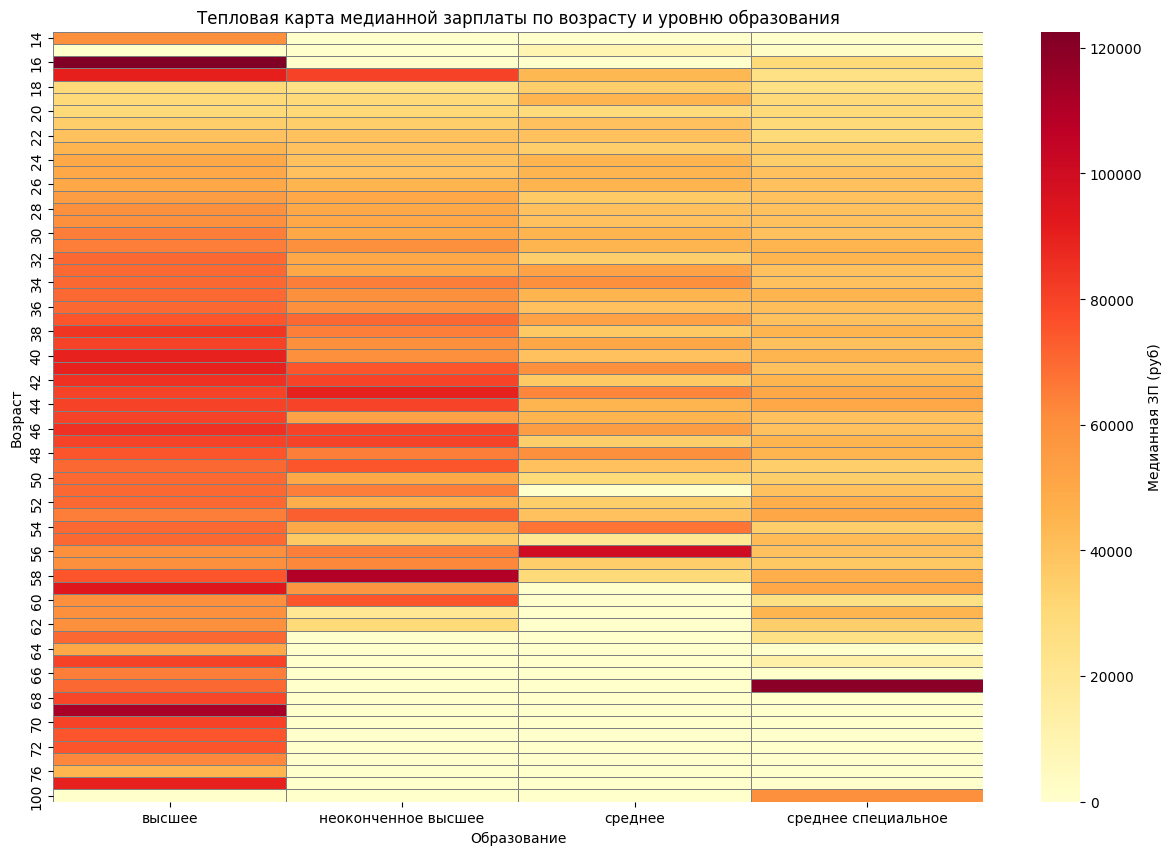

In [22]:
median_salary = merged_data.groupby(['Возраст', 'Образование'])['ЗП (руб)'].median().reset_index()

Piv_table = median_salary.pivot_table(
    values='ЗП (руб)',
    index='Возраст',
    columns='Образование',
    fill_value=0
).round()


plt.figure(figsize=(15, 10))

Piv_table.columns = Piv_table.columns.astype('string')
# Строим тепловую карту
sns.heatmap(
    Piv_table,   
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='gray',
    annot=False, 
    cbar_kws={'label': 'Медианная ЗП (руб)'}
)
plt.title('Тепловая карта медианной зарплаты по возрасту и уровню образования')
plt.xlabel('Образование')
plt.ylabel('Возраст')

plt.show()

**Выводы**:
- Для специалистов со средним и средним специальным образованием наблюдается слабый карьерный рост: медианная заработная плата в среднем остаётся в одном ценовом диапазоне независимо от возраста.

- Для специалистов с незаконченной высшей образовательной подготовкой рост зарплаты с возрастом наблюдается лишь до примерно 58 лет, после чего данные практически отсутствуют, и в таблице значения близки к нулю.

- Для специалистов с высшим образованием медианная зарплата высока на всех возрастных уровнях, при этом у молодых сотрудников она постепенно растёт год от года.
  
  
**Особые наблюдения**:
- Высшее образование, возраст 14 лет — медианная зарплата около 60 тыс. руб., что выше, чем у некоторых более взрослых коллег с аналогичным образованием.

- Высшее образование, возраст 16 лет — медианная зарплата также близка к максимальной (~120 тыс. руб.), что необычно для этой возрастной группы.

- Среднее специальное образование, возраст 67 лет — медианная зарплата примерно максимальная (~120 тыс. руб.), что выбивается из общей тенденции.

- Среднее специальное образование, возраст 100 лет — медианная зарплата примерно такая же, как у 14-летнего сотрудника (~60 тыс. руб.), что тоже необычно.


8. Строю диаграмму рассеяния опыта работы в годах от возраста и добавляю прямую, показывающую равенство опыта и возраста, чтобы выявить аномалии.

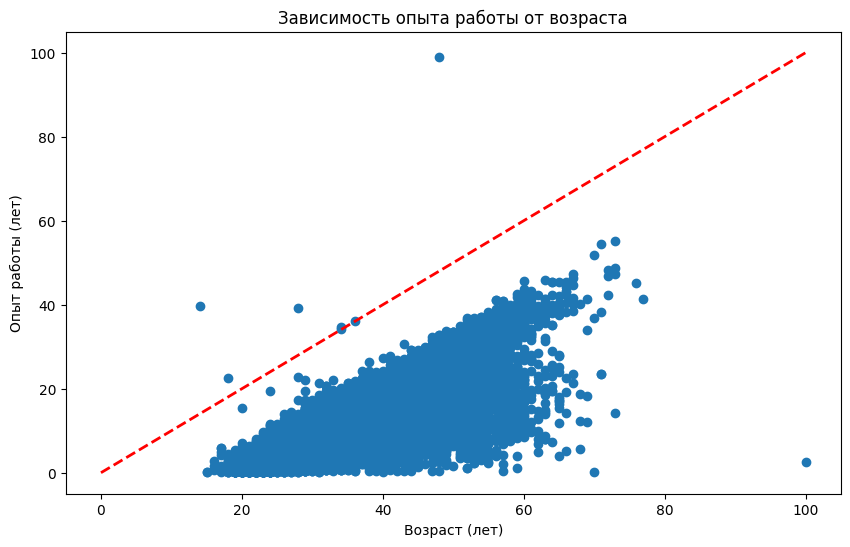

In [23]:
df_plot = merged_data.copy()
df_plot['Опыт работы (годы)'] = df_plot['Опыт работы (месяц)'] / 12

plt.figure(figsize=(10, 6))

plt.scatter(
    data=df_plot, 
    x='Возраст',
    y='Опыт работы (годы)',
)

plt.xlabel('Возраст (лет)')
plt.ylabel('Опыт работы (лет)')
plt.title('Зависимость опыта работы от возраста')

plt.plot(
    [0, 100], [0, 100],
    color='red',
    linestyle='--',
    linewidth=2,
    label='Опыт = Возраст'
)

plt.show()

Основные наблюдения:
- Положительная корреляция: В целом, чем выше возраст, тем больше опыт работы. Это отражено красной пунктирной линией — она показывает идеализированную линейную зависимость.

- Широкое рассеивание точек: Реальные данные сильно варьируются. У людей одного возраста может быть очень разный опыт работы — от нуля до десятков лет.

- Наличие выбросов: молодые люди с опытом работы близким к их возросту, а так же очень пожилиые люди (100 лет) с минимальным опытом 

Выводы:
- Возраст действительно связан с опытом работы, но не является единственным определяющим фактором.

- Общая тенденция сохраняется: с увеличением возраста растёт и трудовой стаж, однако сильное рассеивание подтверждает разнообразие карьерных траекторий.

9. Так же посмотрим графики и проанализируем соотношение мужчин и женщин, а также распределение их заработной платы по половому признаку

In [24]:
# График 1. Соотношение мужчин и женщин
gender_counts = merged_data['Пол'].value_counts().reset_index()
gender_counts.columns = ['Пол', 'Количество']

# Строим круговую диаграмму
fig = px.pie(
    gender_counts,
    names='Пол',
    values='Количество',
    color='Пол',
    height=400,
    width=1000,
    title='Соотношение мужчин и женщин среди всех соискателей',
    color_discrete_map={'М':'blue','Ж':'pink'}
)

fig.show()
fig.write_html("plotly_graphics/Соотношение мужчин и женщин среди всех соискателей - Pie.html")

# График 2. Распределение зароботной платы по половому признаку

fig = px.box(
    merged_data,
    x='ЗП (руб)',
    y='Пол',
    color='Пол',  # добавляет разные цвета для мужчин и женщин
    orientation='h',  # горизонтальная ориентация
    height=400,
    width=1000,
    title='Распределение заработной платы по половому признаку среди соискателей'
)

fig.show()
fig.write_html("plotly_graphics/Распределение заработной платы по половому признаку среди соискателей - Boxplot.html")

Вывод: 
- Мужчины в выборке зарабатывают в среднем больше, при этом их доходы более разнообразны. У женщин зарплаты стабильнее, но реже встречаются высокие значения. Гендерный дисбаланс (преобладание мужчин) может частично объяснять разницу в уровне оплаты труда и требует дополнительного анализа с учётом должностей и опыта.

## Очистка данных

1. Начнем с дубликатов в наших данных. Найдем **полные дубликаты** в таблице с резюме и удалим их. 

In [25]:
# Найти все полные дубликаты
duplicates_mask = merged_data.duplicated()

# Посчитать их количество
num_duplicates = duplicates_mask.sum()
print(f'Найдено полных дубликатов: {num_duplicates}')

# Удалить дубликаты
merged_data = merged_data.drop_duplicates()

Найдено полных дубликатов: 161


2. Займемся пропусками. Найдем количество **пропусков** в каждом из столбцов. 

In [26]:
missing_counts = merged_data.isnull().sum()
print(missing_counts)

Ищет работу на должность:            0
Последнее/нынешнее место работы      1
Последняя/нынешняя должность         2
Обновление резюме                    0
Авто                                 0
Образование                          0
Пол                                  0
Возраст                              0
Опыт работы (месяц)                168
Город                                0
Готовность к переезду                0
Готовность к командировкам           0
стажировка                           0
волонтерство                         0
полная занятость                     0
проектная работа                     0
частичная занятость                  0
гибкий график                        0
полный день                          0
сменный график                       0
удаленная работа                     0
вахтовый метод                       0
ЗП (руб)                             0
dtype: int64


3. У нас есть пропуски в трёх столбцах: "Опыт работы (месяц)", "Последнее/нынешнее место работы" и "Последняя/нынешняя должность".  
Удалим строки, где отсутствуют данные о месте работы или должности, а пропуски в опыте работы заполним медианным значением.

In [27]:
merged_data = merged_data.dropna(subset=['Последнее/нынешнее место работы', 'Последняя/нынешняя должность'])
median_experience = merged_data['Опыт работы (месяц)'].median()
merged_data['Опыт работы (месяц)'] = merged_data['Опыт работы (месяц)'].fillna(median_experience)
print(merged_data.isnull().sum())

mean_experience = merged_data['Опыт работы (месяц)'].mean()
print(round(mean_experience))

Ищет работу на должность:          0
Последнее/нынешнее место работы    0
Последняя/нынешняя должность       0
Обновление резюме                  0
Авто                               0
Образование                        0
Пол                                0
Возраст                            0
Опыт работы (месяц)                0
Город                              0
Готовность к переезду              0
Готовность к командировкам         0
стажировка                         0
волонтерство                       0
полная занятость                   0
проектная работа                   0
частичная занятость                0
гибкий график                      0
полный день                        0
сменный график                     0
удаленная работа                   0
вахтовый метод                     0
ЗП (руб)                           0
dtype: int64
114


4. Очистка аномалий в данных по зарплате: Удалим резюме с заработной платой выше 1 млн ₽ или ниже 1 тыс ₽.

In [28]:
# Считаем выбросы
outliers = merged_data[(merged_data['ЗП (руб)'] > 1_000_000) | (merged_data['ЗП (руб)'] < 1_000)]
print(len(outliers))


merged_data = merged_data[(merged_data['ЗП (руб)'] <= 1_000_000) & (merged_data['ЗП (руб)'] >= 1_000)]

89


5. Удалим резюме, где опыт работы в месяцах превышает возраст соискателя.

In [29]:
merged_data['Опыт работы (годы)'] = merged_data['Опыт работы (месяц)'] / 12 
anomalies = merged_data[merged_data['Опыт работы (годы)'] > merged_data['Возраст']]
print(len(anomalies))

merged_data = merged_data[merged_data['Опыт работы (годы)'] <= merged_data['Возраст']]
merged_data = merged_data.drop(columns=['Опыт работы (годы)'])

7


6. Построим график распределения признака "Возраст" в логарифмическом масштабе для выявления аномальных значений (очень пожилые соискатели). Добавим линии среднего и границ интервала по методу трёх сигм. На основе логарифмического распределения определим выбросы (4 сигмы справа) и удалим их из данных.

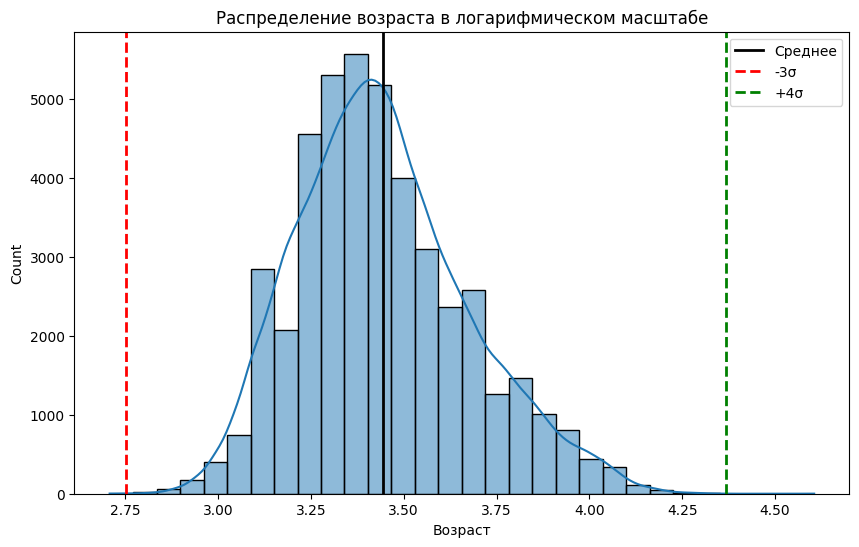

      Пол  Возраст  ЗП (руб)
31137   M       15   10000.0
32950   M       15    2000.0
33654   M      100   60000.0


In [30]:
log_age = np.log(merged_data['Возраст'])

# Построим гистограмму
plt.figure(figsize=(10,6))
histplot = sns.histplot(log_age, bins=30, kde=True)
plt.title('Распределение возраста в логарифмическом масштабе')
mean_log = log_age.mean()
std_log = log_age.std()
histplot.axvline(mean_log, color='k', lw=2, label='Среднее')
histplot.axvline(mean_log - 3*std_log, color='r', lw=2, linestyle='--', label='-3σ')
histplot.axvline(mean_log + 4*std_log, color='g', lw=2, linestyle='--', label='+4σ')
plt.legend()
plt.show()

# Вычислим z-отклонения и найдем выбросы
z_scores = (log_age - mean_log) / std_log
outliers = merged_data[(z_scores < -3) | (z_scores > 4)]
print(outliers[['Пол', 'Возраст', 'ЗП (руб)']])

# Удалим эти выбросы из данных
merged_data = merged_data[(z_scores >= -3) & (z_scores <= 4)]

Вывод:
- распределение возраста в логарифмическом масштабе асимметрично влево (отрицательная асимметрия).
- под категорию выбросов по возрасту попадают очень молодые соискатели 15 лет и очень старые 100 лет 